# **DSC530 – Data Exploration and Analysis**

## **Timothy Hollis**  
## **Week 5 & 6 Coding Assignment**  
## **February 1, 2026**

<hr style='height:3px; background-color:#333; border:none; margin:30px 0;'>

## **Assignment Overview**

This notebook contains Chapter 4 exercises from *Hands-On Data Analysis with Pandas* (2nd Edition) for DSC530 – Data Exploration and Analysis, and uses the following Datasets to complete them:

- Earthquake events (USGS)  
- FAANG stock prices (Facebook, Amazon, Apple, Netflix, Google)  
- Global COVID-19 case reports (ECDC)  


<hr style='height:2px; background-color:#999; border:none; margin:30px 0;'>

## **Initial Setup**

The following code cell loads required libraries, sets global display and plotting options, and imports the three primary datasets used throughout the assignment.

In [1]:
# Load Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from IPython.display import display, Markdown

# Visualization style and color palettes
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
earthquake_colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
faang_colors = ['#3A86FF', '#FF006E', '#8338EC', '#FB5607', '#38B000']
covid_colors = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51']

# Global figure settings
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'font.size': 13,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'grid.alpha': 0.25,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold'
})

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Display settings for cleaner tables
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 140)
pd.set_option('display.precision', 4)
pd.set_option('display.float_format',
              lambda x: f'{x:,.2f}' if abs(x) >= 1e3 else f'{x:.4f}' if abs(x) >= 0.01 else f'{x:.6f}')
pd.set_option('display.max_colwidth', 120)

# Base path and dataset loading
BASE_PATH = Path('.')
earthquakes = pd.read_csv(BASE_PATH / 'earthquakes.csv')
faang = pd.read_csv(BASE_PATH / 'faang.csv')
covid = pd.read_csv(BASE_PATH / 'covid19_cases.csv')

# Date Parsing
faang['date'] = pd.to_datetime(faang['date'])
faang = faang.sort_values('date').set_index('date')
covid['dateRep'] = pd.to_datetime(covid['dateRep'], format='%d/%m/%Y')

# Confirmation message
print("All datasets loaded successfully:")
print(
    f" • earthquakes: {earthquakes.shape[0]:,} rows × {earthquakes.shape[1]} columns")
print(
    f" • faang      : {faang.shape[0]:,} rows × {faang.shape[1]} columns (date indexed)")
print(f" • covid      : {covid.shape[0]:,} rows × {covid.shape[1]} columns\n")

# Preview the first row of each dataset to confirm structure
display(Markdown("### First Row – Earthquakes"))
display(earthquakes.head(1))

display(Markdown("### First Row – FAANG Stocks (date parsed & indexed)"))
display(faang.head(1))

display(Markdown("### First Row – COVID-19 Cases (dateRep parsed)"))
display(covid.head(1))

All datasets loaded successfully:
 • earthquakes: 9,332 rows × 6 columns
 • faang      : 1,255 rows × 6 columns (date indexed)
 • covid      : 43,718 rows × 12 columns



### First Row – Earthquakes

,mag,magType,time,place,tsunami,parsed_place
0,1.3500,ml,1539475168010,"9km NE of Aguanga, CA",0,California


### First Row – FAANG Stocks (date parsed & indexed)

,ticker,high,low,open,close,volume
date,,,,,,
2018-01-02,FB,181.5800,177.5500,177.6800,181.4200,"18,151,900.00"


### First Row – COVID-19 Cases (dateRep parsed)

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000
0,2020-09-19,19,9,2020,47,1,Afghanistan,AF,AFG,"38,041,757.00",Asia,1.6166


<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## **Chapter 4 – Exercise 1: Earthquakes in Japan with mb Magnitude ≥ 4.9**

### Task
With the `earthquakes.csv` file, select all the earthquakes in Japan with a magnitude of 4.9 or greater using the **mb** magnitude type.

### Steps
1. Filter rows where `parsed_place` contains "Japan" (case-insensitive)  
2. Keep only rows where `magType` is exactly "mb"  
3. Select events with `mag` ≥ 4.9  
4. Combine all conditions into a single boolean mask using `&`  
5. Apply the mask and display the resulting subset (showing key columns like time, place, mag, etc.)

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

Found 4 significant earthquakes in Japan
Time range: 2018-10-02 to 2018-10-08
Magnitude range: 4.9 to 5.4



,time,mag,place
0,2018-10-02 03:27,4.9,"53km ESE of Hitachi, Japan"
1,2018-10-03 15:15,4.9,"15km ENE of Hasaki, Japan"
2,2018-10-04 23:58,5.4,"37km E of Tomakomai, Japan"
3,2018-10-08 05:45,4.9,"293km ESE of Iwo Jima, Japan"


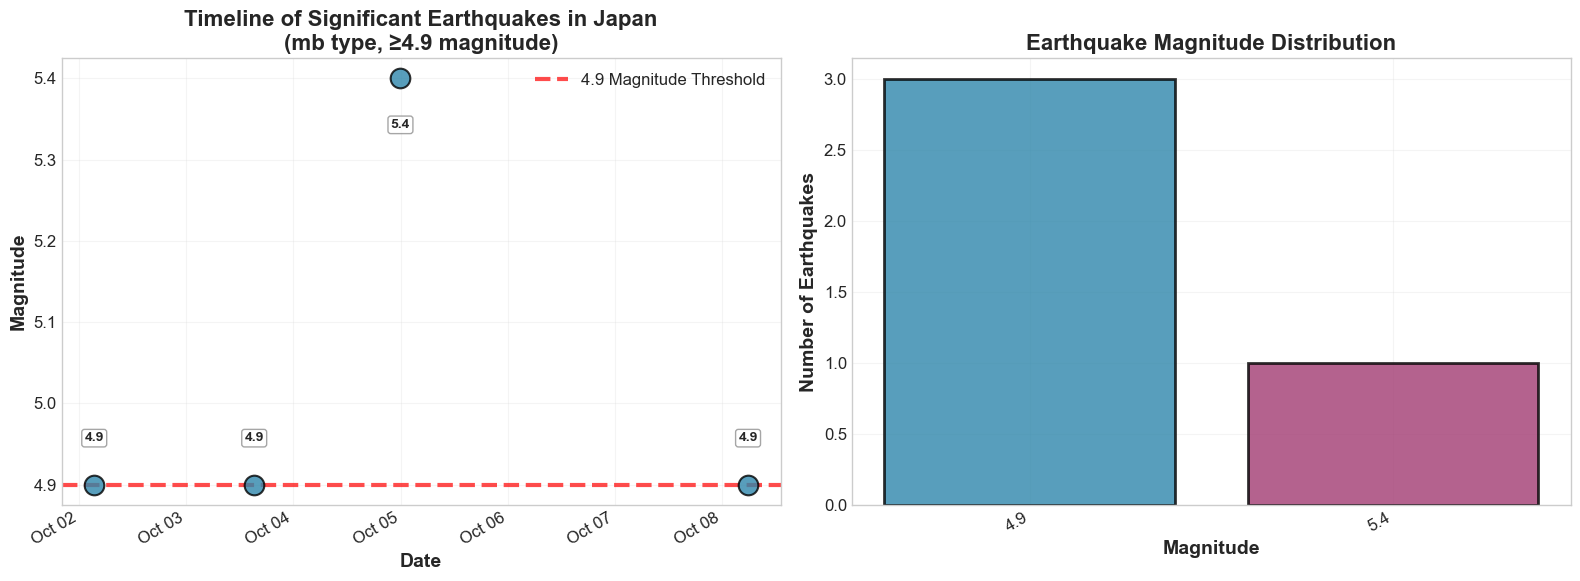

In [2]:
# 1. Find earthquakes in Japan
in_japan = earthquakes['parsed_place'].str.contains(
    'Japan', case=False, na=False)

# 2. Filter for 'mb' magnitude type
is_mb = earthquakes['magType'] == 'mb'

# 3. Get earthquakes magnitude 4.9 or higher
mag_49_plus = earthquakes['mag'] >= 4.9

# 4. Combine all filters
japan_big_quakes = earthquakes[in_japan & is_mb & mag_49_plus].copy()

# Convert timestamp from milliseconds to datetime
japan_big_quakes.loc[:, 'time'] = pd.to_datetime(
    japan_big_quakes['time'], unit='ms')

# Sort chronologically
japan_big_quakes = japan_big_quakes.sort_values('time').reset_index(drop=True)

# Show results with visual
if japan_big_quakes.empty:
    print("No earthquakes in Japan met the criteria (mb magnitude ≥ 4.9).")
else:
    print(f"Found {len(japan_big_quakes)} significant earthquakes in Japan")
    print(
        f"Time range: {japan_big_quakes['time'].min().date()} to "
        f"{japan_big_quakes['time'].max().date()}")
    print(
        f"Magnitude range: {japan_big_quakes['mag'].min():.1f} to "
        f"{japan_big_quakes['mag'].max():.1f}\n")
    display(
        japan_big_quakes[['time', 'mag', 'place']]
        .style
        .background_gradient(subset=['mag'], cmap='YlOrRd')
        .format({
            'time': '{:%Y-%m-%d %H:%M}',
            'mag': '{:.1f}'
        })
        .set_caption("Significant Earthquakes in Japan (mb ≥ 4.9)")
    )
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Timeline
    ax1.scatter(
        japan_big_quakes['time'], japan_big_quakes['mag'],
        color=earthquake_colors[0], s=200, alpha=0.8,
        edgecolor='black', linewidth=1.5, zorder=3
    )
    for _, row in japan_big_quakes.iterrows():
        mag = row['mag']
        label = f"{mag:.1f}"

        if mag == japan_big_quakes['mag'].max():
            # Offset highest (placing label BELOW the point to avoid covering
            # title)
            y_offset = -0.05
            va = 'top'
        else:
            y_offset = 0.05
            va = 'bottom'

        ax1.text(
            row['time'], row['mag'] + y_offset, label,
            ha='center', va=va, fontsize=10, fontweight='bold',
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor='white',
                alpha=0.7,
                edgecolor='gray'
            )
        )

    ax1.axhline(
        y=4.9, color='red', linestyle='--', linewidth=3, alpha=0.7,
        label='4.9 Magnitude Threshold'
    )
    ax1.set_xlabel('Date', fontweight='bold')
    ax1.set_ylabel('Magnitude', fontweight='bold')
    ax1.set_title(
        'Timeline of Significant Earthquakes in Japan\n(mb type, ≥4.9 magnitude)',
        fontsize=16, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.2)
    ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %d'))
    fig.autofmt_xdate()

    # Magnitude distribution
    magnitude_counts = japan_big_quakes['mag'].value_counts().sort_index()
    x_pos = np.arange(len(magnitude_counts))
    colors = [earthquake_colors[i % len(earthquake_colors)]
              for i in range(len(magnitude_counts))]

    bars = ax2.bar(
        x_pos, magnitude_counts.values,
        color=colors,
        edgecolor='black', linewidth=2, alpha=0.8
    )

    ax2.set_xlabel('Magnitude', fontweight='bold')
    ax2.set_ylabel('Number of Earthquakes', fontweight='bold')
    ax2.set_title(
        'Earthquake Magnitude Distribution',
        fontsize=16, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'{mag:.1f}' for mag in magnitude_counts.index])
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

### Summary

**Filtering Strategy**  
This exercise used a set of boolean masks to isolate earthquakes in Japan meeting all three criteria. Each condition was applied independently, keeping the logic readable and verifiable:

1. **Location filter**: `.str.contains('Japan', case=False)` for flexible matching across varied place descriptions  
2. **Magnitude type filter**: `magType == 'mb'` to ensure consistent measurement scale  
3. **Magnitude threshold filter**: `mag >= 4.9` to focus on stronger events  

**Key Operations Used**  
- `.str.contains()` for robust text matching  
- Boolean operators (`&`) to combine conditions cleanly  
- `.copy()` to avoid `SettingWithCopyWarning` when modifying filtered data  
- `pd.to_datetime(unit='ms')` to convert timestamps for readable plotting  

**Why This Approach Works Well**  
- Each filter is simple, testable, and easy to modify  
- The combined logic reads naturally: “in Japan AND mb type AND magnitude ≥ 4.9”  
- Boolean masks are efficient and scale well to larger datasets  
- The approach keeps code transparent, maintainable, and easy to debug  

**Potential Alternative Approaches**  
- Chained `.loc[]` calls (functional but less readable)  
- A custom filtering function with `apply()` (unnecessary overhead here)  

**Takeaway**  
Boolean masking with separate, clearly named conditions is often the most readable and maintainable way to perform multi-criteria filtering in pandas. Adding visualizations (timeline and distribution plots) further enhances interpretation and pattern recognition.

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## **Chapter 4 – Exercise 2: Binning Earthquake Magnitudes (ml type)**

### Task
Using the `earthquakes.csv` file, create bins for each full number of earthquake magnitude (for instance, the first bin is (0,1], the second is (1,2], and so on) with the **ml** magnitude type and count how many are in each bin.

### Steps
1. Filter the dataset to include only earthquakes where `magType == 'ml'`  
2. Extract the `mag` column and determine its min/max (accounting for possible negative values) to define bin edges  
3. Use `pd.cut()` to assign each magnitude to its appropriate bin (right-closed intervals)  
4. Use `value_counts()` to count events per bin and sort the index for natural order  
5. Display the results in tabular form (counts per bin) and visually (bar plot or histogram) for quick interpretation  

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

📊 Working with 6,803 earthquakes measured with 'ml' type
📈 Magnitude range: -1.3 to 5.1

🔢 Creating bins from -2 to 6 in 1-unit increments
 Bins: [(np.float64(-2.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(0.0)), (np.float64(0.0), np.float64(1.0)), (np.float64(1.0), np.float64(2.0)), (np.float64(2.0), np.float64(3.0)), (np.float64(3.0), np.float64(4.0)), (np.float64(4.0), np.float64(5.0)), (np.float64(5.0), np.float64(6.0))]

📋 Magnitude Distribution Summary:


,Magnitude Range,Earthquake Count,Percentage
0,-2–-1,13,0.19%
1,-1–0,491,7.22%
2,0–1,"2,207",32.44%
3,1–2,"3,105",45.64%
4,2–3,862,12.67%
5,3–4,122,1.79%
6,4–5,2,0.03%
7,5–6,1,0.01%


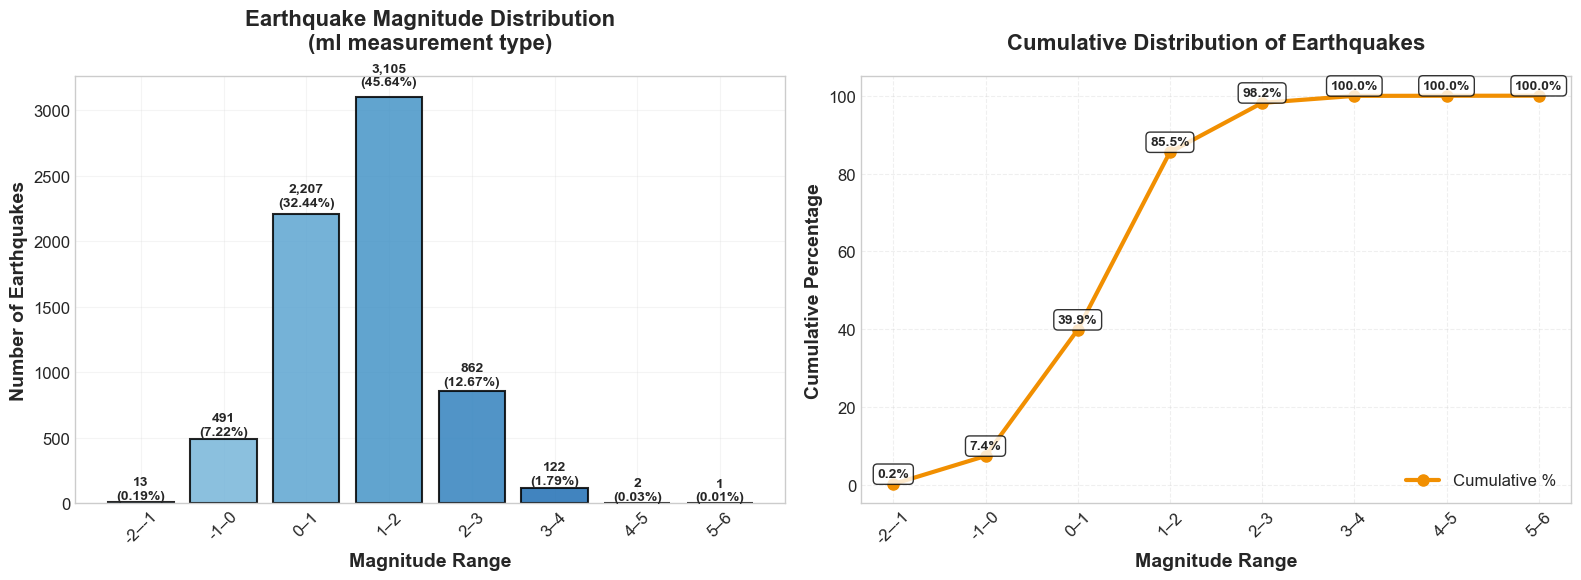


📊 Quick Bin Statistics:
 • Most common range: (1.0, 2.0] with 3,105 earthquakes
 • Total earthquakes binned: 6,803
 • Number of bins created: 8


In [3]:
# 1. Filter for 'ml' magnitude type
ml_earthquakes = earthquakes[earthquakes['magType'] == 'ml'].copy()

print(
    f"📊 Working with {len(ml_earthquakes):,} earthquakes measured with 'ml' type")
print(
    f"📈 Magnitude range: {ml_earthquakes['mag'].min():.1f} to {ml_earthquakes['mag'].max():.1f}\n")

# 2. Determine bin edges
min_mag = np.floor(ml_earthquakes['mag'].min())
max_mag = np.ceil(ml_earthquakes['mag'].max())
bins = np.arange(min_mag, max_mag + 1, 1)

print(
    f"🔢 Creating bins from {min_mag:.0f} to {max_mag:.0f} in 1-unit increments")
print(f" Bins: {list(zip(bins[:-1], bins[1:]))}\n")

# 3. Assign each magnitude to a bin
ml_earthquakes['magnitude_bin'] = pd.cut(
    ml_earthquakes['mag'],
    bins=bins,
    right=True,
    include_lowest=True,
    precision=1
)

# 4. Count earthquakes in each bin
bin_counts = ml_earthquakes['magnitude_bin'].value_counts().sort_index()

# 5. Create visual
bin_summary = pd.DataFrame({
    'Magnitude Range': [f"{int(bin.left)}–{int(bin.right)}" for bin in bin_counts.index],
    'Earthquake Count': bin_counts.values,
    'Percentage': (bin_counts.values / len(ml_earthquakes) * 100).round(2)
})

print("📋 Magnitude Distribution Summary:")
display(
    bin_summary.style
    .bar(subset=['Earthquake Count'], color='#2E86AB', vmin=0)
    .bar(subset=['Percentage'], color='#A23B72', vmin=0)
    .format({'Earthquake Count': '{:,}', 'Percentage': '{:.2f}%'})
)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
x_pos = np.arange(len(bin_counts))
bars = ax1.bar(
    x_pos, bin_counts.values,
    color=plt.cm.Blues(np.linspace(0.4, 0.9, len(bin_counts))),
    edgecolor='black', linewidth=1.5, alpha=0.85
)
ax1.set_xlabel('Magnitude Range', fontweight='bold')
ax1.set_ylabel('Number of Earthquakes', fontweight='bold')
ax1.set_title(
    'Earthquake Magnitude Distribution\n(ml measurement type)',
    fontsize=16, fontweight='bold', pad=20
)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(
    [f"{int(bin.left)}–{int(bin.right)}" for bin in bin_counts.index],
    rotation=45
)
for bar, count, percentage in zip(
        bars, bin_counts.values, bin_summary['Percentage']):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2., height + (height * 0.02),
        f'{count:,}\n({percentage}%)',
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', linespacing=1.2
    )
ax1.grid(True, alpha=0.2, zorder=0)

# Cumulative distribution
cumulative_percentage = (bin_counts.cumsum() / len(ml_earthquakes) * 100)
ax2.plot(
    x_pos, cumulative_percentage.values,
    marker='o', markersize=8, linewidth=3,
    color=earthquake_colors[2], label='Cumulative %'
)
ax2.set_xlabel('Magnitude Range', fontweight='bold')
ax2.set_ylabel('Cumulative Percentage', fontweight='bold')
ax2.set_title(
    'Cumulative Distribution of Earthquakes',
    fontsize=16, fontweight='bold', pad=20
)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(
    [f"{int(bin.left)}–{int(bin.right)}" for bin in bin_counts.index],
    rotation=45
)
ax2.grid(True, alpha=0.3, linestyle='--')
for i, cum_pct in enumerate(cumulative_percentage):
    ax2.text(
        i, cum_pct + 1, f'{cum_pct:.1f}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8)
    )
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Quick statistics
print("\n📊 Quick Bin Statistics:")
print(
    f" • Most common range: {bin_counts.idxmax()} with {bin_counts.max():,} earthquakes")
print(f" • Total earthquakes binned: {bin_counts.sum():,}")
print(f" • Number of bins created: {len(bins) - 1}")

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

### Summary

**Binning Strategy**  
This exercise grouped earthquake magnitudes (using only the `ml` measurement type) into clean, full-number intervals. Binning makes it easier to see how magnitudes are distributed across the dataset and highlights which ranges occur most frequently:

1. **Magnitude type filter**: Only `ml` measurements were included to keep the analysis consistent  
2. **Bin creation**: Full-number bins were generated dynamically from the minimum to the maximum magnitude  
3. **Categorization**: `pd.cut()` assigned each earthquake to its appropriate magnitude range  
4. **Counting**: Each bin was tallied and converted into both counts and percentages  
5. **Visualization**: A bar chart and cumulative distribution curve provided two perspectives on the data  

**Key Operations Used**  
- `np.arange()` to generate evenly spaced bin edges  
- `pd.cut()` to categorize magnitudes into intervals  
- `.value_counts()` to compute bin frequencies  
- Cumulative sums to show how quickly percentages accumulate across bins  

**Why This Approach Works Well**  
- Binning simplifies a continuous variable into interpretable groups  
- Full-number bins make the results intuitive and easy to compare  
- The combination of counts, percentages, and cumulative percentages gives a complete picture of the distribution  
- Visualizations reinforce the numerical summary and highlight trends at a glance  

**Potential Alternative Approaches**  
- Using `pd.qcut()` to create quantile-based bins  
- Applying custom bin widths (e.g., 0.5-unit bins) for finer resolution  
- Kernel density estimation for a smooth distribution curve  

**Takeaway**  
Binning with `pd.cut()` provides a clear, structured way to understand how earthquake magnitudes are distributed, making it easier to compare frequency patterns and identify where most events occur. Dynamic bin creation and multi-view plots enhance interpretability for exploratory analysis.

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## **Chapter 4 – Exercise 4: Tsunami vs. Magnitude Type Crosstab**

### Task
Build a crosstab with the earthquake data between the tsunami column and the magType column. Rather than showing the frequency count, show the **maximum magnitude** that was observed for each combination. Put the magnitude type along the columns.

### Steps
1. Use `pd.crosstab()` with `tsunami` as index (rows) and `magType` as columns  
2. Pass the `mag` column as `values` to aggregate magnitudes instead of counts  
3. Set `aggfunc='max'` to show the maximum magnitude for each combination  
4. Sort the columns alphabetically for consistent readability  
5. Display the table (with optional styling to highlight higher values) and interpret key patterns  

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

 Dataset size: 9,332 earthquakes
 Tsunami events: 61
 Unique magnitude types: 10

📊 Maximum Magnitude by Tsunami Status and Magnitude Type:


magType,Max Overall,mb,mb_lg,md,mh,ml,ms_20,mw,mwb,mwr,mww
No Tsunami,6.00,5.60,3.50,4.11,1.10,4.20,nan,3.83,5.80,4.80,6.00
Tsunami Occurred,7.50,6.10,nan,nan,nan,5.10,5.70,4.41,nan,nan,7.50
Max Overall,7.50,6.10,3.50,4.11,1.10,5.10,5.70,4.41,5.80,4.80,7.50



📈 For comparison: Average Magnitude by Tsunami Status and Magnitude Type:


magType,mb,mb_lg,md,mh,ml,ms_20,mw,mwb,mwr,mww
No Tsunami,4.53,2.65,1.32,0.52,1.22,nan,3.59,5.75,4.39,5.45
Tsunami Occurred,5.30,nan,nan,nan,4.42,5.70,4.12,nan,nan,5.68


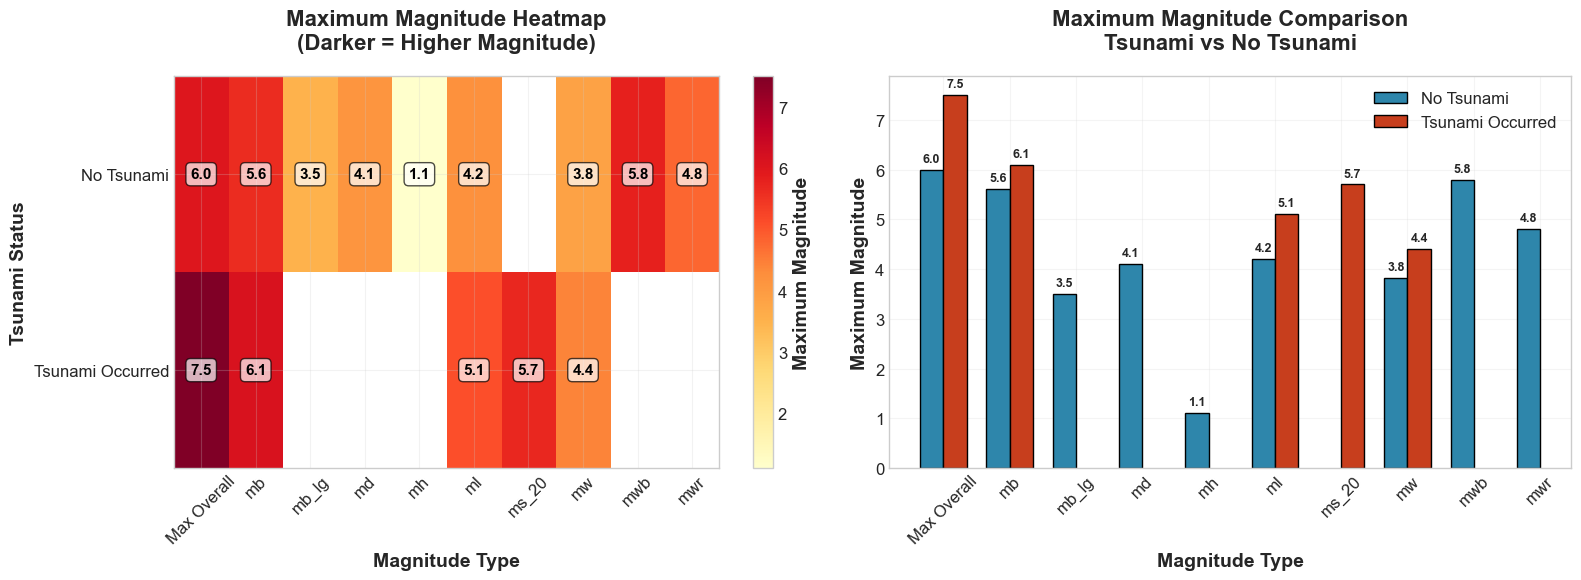


🔍 Quick Observations from the Crosstab:
 • Max Overall: Tsunami events had magnitude +1.5 higher
 • mb: Tsunami events had magnitude +0.5 higher
 • mb_lg: No data for one or both categories
 • md: No data for one or both categories
 • mh: No data for one or both categories
 • ml: Tsunami events had magnitude +0.9 higher
 • ms_20: No data for one or both categories
 • mw: Tsunami events had magnitude +0.6 higher
 • mwb: No data for one or both categories
 • mwr: No data for one or both categories


In [4]:
print(f" Dataset size: {len(earthquakes):,} earthquakes")
print(f" Tsunami events: {(earthquakes['tsunami'] == 1).sum():,}")
print(f" Unique magnitude types: {earthquakes['magType'].nunique()}")
print()

# 1. Create the crosstab with max magnitude
crosstab_result = pd.crosstab(
    index=earthquakes['tsunami'],
    columns=earthquakes['magType'],
    values=earthquakes['mag'],
    aggfunc='max',
    margins=True,
    margins_name='Max Overall'
)
crosstab_result = crosstab_result[sorted(
    crosstab_result.columns)]  # Sorting alphebetically

# Convert tsunami codes to descriptive labels
crosstab_result.index = ['No Tsunami', 'Tsunami Occurred', 'Max Overall']

print("📊 Maximum Magnitude by Tsunami Status and Magnitude Type:")
display(
    crosstab_result.style
    .background_gradient(cmap='YlOrRd', axis=None)
    .format('{:.2f}')
    .set_caption('Maximum Magnitude for Each Combination')
    .set_properties(**{'text-align': 'center'})
)

# Added comparison
print("\n📈 For comparison: Average Magnitude by Tsunami Status and Magnitude Type:")
crosstab_avg = pd.crosstab(
    index=earthquakes['tsunami'],
    columns=earthquakes['magType'],
    values=earthquakes['mag'],
    aggfunc='mean'
)
crosstab_avg.index = ['No Tsunami', 'Tsunami Occurred']
display(
    crosstab_avg.style
    .background_gradient(cmap='Blues', axis=None)
    .format('{:.2f}')
    .set_caption('Average Magnitude for Each Combination')
    .set_properties(**{'text-align': 'center'})
)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of max magnitudes
heatmap_data = crosstab_result.iloc[:-1, :-1]  # Exclude margins
im = ax1.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto')
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        value = heatmap_data.iloc[i, j]
        if not np.isnan(value):
            ax1.text(j, i, f'{value:.1f}',
                     ha='center', va='center', color='black',
                     fontsize=11, fontweight='bold',
                     bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

ax1.set_xticks(range(len(heatmap_data.columns)))
ax1.set_xticklabels(heatmap_data.columns, rotation=45)
ax1.set_yticks(range(len(heatmap_data.index)))
ax1.set_yticklabels(heatmap_data.index)
ax1.set_xlabel('Magnitude Type', fontweight='bold')
ax1.set_ylabel('Tsunami Status', fontweight='bold')
ax1.set_title('Maximum Magnitude Heatmap\n(Darker = Higher Magnitude)',
              fontsize=16, fontweight='bold', pad=20)
plt.colorbar(im, ax=ax1, label='Maximum Magnitude')

# Bar chart comparison (no tsunami vs tsunami)
mag_types = heatmap_data.columns
no_tsunami = heatmap_data.loc['No Tsunami']
with_tsunami = heatmap_data.loc['Tsunami Occurred']
x = np.arange(len(mag_types))
width = 0.35

bars1 = ax2.bar(x - width/2, no_tsunami, width,
                label='No Tsunami', color='#2E86AB', edgecolor='black')
bars2 = ax2.bar(x + width/2, with_tsunami, width,
                label='Tsunami Occurred', color='#C73E1D', edgecolor='black')

ax2.set_xlabel('Magnitude Type', fontweight='bold')
ax2.set_ylabel('Maximum Magnitude', fontweight='bold')
ax2.set_title('Maximum Magnitude Comparison\nTsunami vs No Tsunami',
              fontsize=16, fontweight='bold', pad=20)
ax2.set_xticks(x)
ax2.set_xticklabels(mag_types, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.2, zorder=0)


def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                     f'{height:.1f}', ha='center', va='bottom',
                     fontsize=9, fontweight='bold')


autolabel(bars1)
autolabel(bars2)

plt.tight_layout()
plt.show()

# Added stats
print("\n🔍 Quick Observations from the Crosstab:")
for mag_type in heatmap_data.columns:
    no_tsunami_max = heatmap_data.loc['No Tsunami', mag_type]
    tsunami_max = heatmap_data.loc['Tsunami Occurred', mag_type]
    diff = tsunami_max - no_tsunami_max
    if np.isnan(diff):
        print(f" • {mag_type}: No data for one or both categories")
    else:
        print(f" • {mag_type}: Tsunami events had magnitude {diff:+.1f} higher")

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

### Summary

**Core Method**  
This exercise used `pd.crosstab()` with a custom aggregation function to compare tsunami occurrence against magnitude type. By supplying the `mag` column as the `values` argument and using `aggfunc='max'`, the crosstab highlights the strongest recorded magnitude for each category pairing — revealing severity patterns rather than just counts.

**Key Parameters Used**  
- **`values`** — selects the numerical column to aggregate  
- **`aggfunc`** — specifies the aggregation function (`'max'` in this case)  
- **`margins=True`** — adds row and column totals automatically  
- **`margins_name`** — assigns a custom label to the totals row/column  

**Data Transformation Insights**  
1. **Multi-dimensional aggregation**: Groups by two categorical variables while computing a numerical statistic  
2. **Missing combinations**: NaN values naturally appear where no observations exist  
3. **Label cleanup**: Replacing 0/1 tsunami codes with descriptive labels improves readability  

**Why This Approach Works Well**  
- Produces a clean summary table with a single function call  
- Supports flexible aggregation (max, mean, min, sum, etc.)  
- Automatically structures the output into a readable matrix  
- The margins feature provides quick totals without extra code  
- Visualizations (heatmap and grouped bar chart) reinforced the numerical findings by highlighting magnitude differences visually  

**Alternative Approaches**  
- **Nested `.groupby()`** — would be highly customizable  
- **`.pivot_table()`** — similar functionality with different syntax  
- **Manual aggregation** — possible but unnecessarily complex  

**Performance Consideration**  
`pd.crosstab()` is optimized for frequency-style tables and handles large datasets efficiently. Using NumPy-backed aggregation functions keeps computations fast.

**Practical Application**  
This technique is ideal for exploring relationships between categorical variables while summarizing numerical metrics — useful in survey analysis, A/B testing, operational dashboards, and any scenario where group comparisons matter.

**Takeaway**  
Crosstabs with targeted aggregation (beyond simple counts) provide powerful, concise insights into categorical-numerical relationships, making complex patterns easy to interpret at a glance.

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## **Chapter 4 – Exercise 6: FAANG Stock Comparison Pivot Table**

### Task
With the `faang.csv` file, build a pivot table that shows the average of the open, high, low, close, and volume for each ticker.

### Steps
1. Confirm the `faang` DataFrame (already date-indexed from setup) and select the OHLC + volume columns  
2. Build a pivot table with `ticker` as the index (rows)  
3. Specify the OHLCV columns as `values` and `aggfunc='mean'`  
4. Format the results for readability (e.g., round to 2 decimals, sort by ticker)  
5. Visualize the differences across FAANG stocks for quick comparison  

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

 Total records: 1,255
 Unique tickers: 5
 Tickers found: ['AAPL', 'AMZN', 'FB', 'GOOG', 'NFLX']

📋 Average OHLC + Volume for Each FAANG Stock:


,close,high,low,open,volume
ticker,,,,,
AAPL,47.26,47.75,46.80,47.28,"136,080,258"
AMZN,"1,641.73","1,662.84","1,619.84","1,644.07","5,648,994"
FB,171.51,173.61,169.30,171.47,"27,658,597"
GOOG,"1,113.23","1,125.78","1,101.00","1,113.55","1,741,965"
NFLX,319.29,325.22,313.19,319.62,"11,469,625"


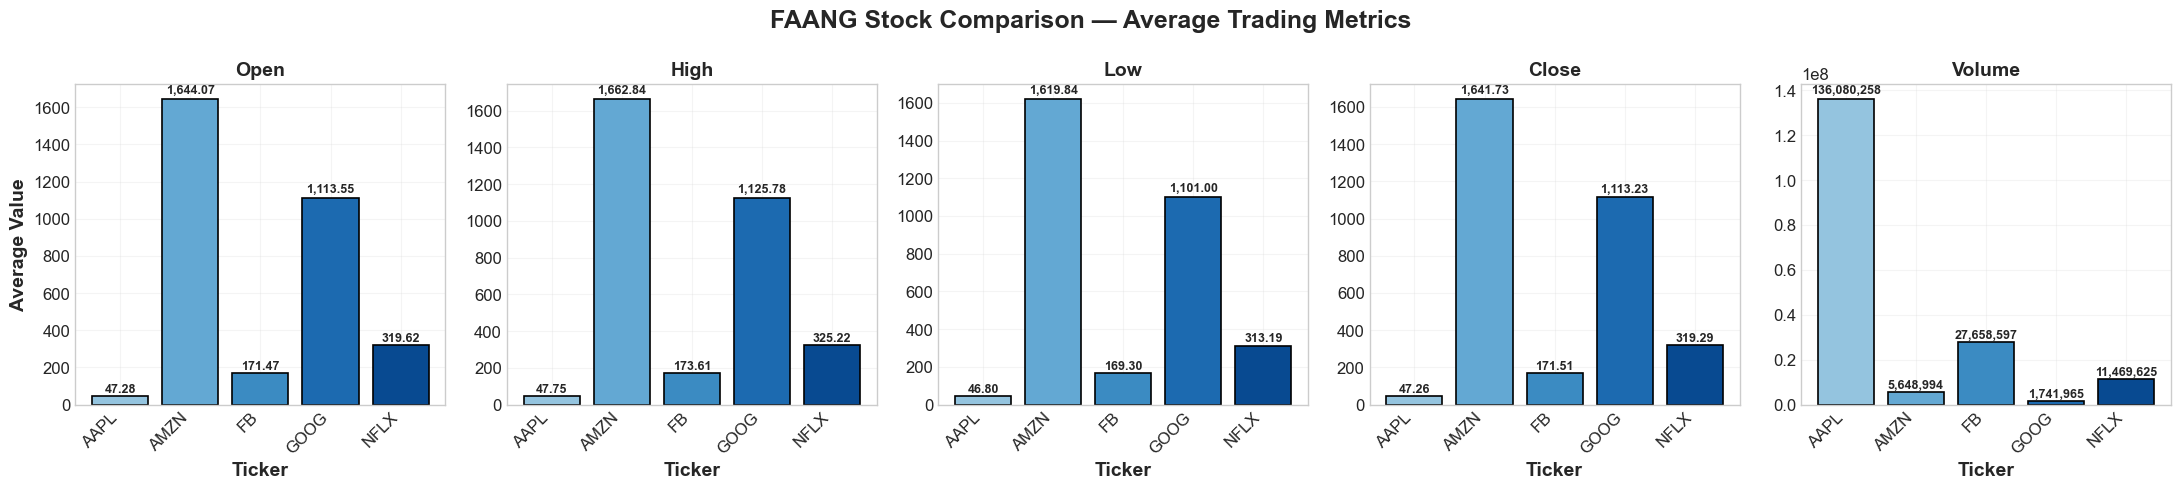


🔍 Quick Observations:
 • Open: Highest average value from AMZN (1,644.07)
 • High: Highest average value from AMZN (1,662.84)
 • Low: Highest average value from AMZN (1,619.84)
 • Close: Highest average value from AMZN (1,641.73)
 • Volume: Highest average value from AAPL (136,080,258.17)


In [5]:
# 1. Select only the OHLC and volume columns
faang_metrics = faang[['ticker', 'open',
                       'high', 'low', 'close', 'volume']].copy()

print(f" Total records: {len(faang_metrics):,}")
print(f" Unique tickers: {faang_metrics['ticker'].nunique()}")
print(f" Tickers found: {sorted(faang_metrics['ticker'].unique())}\n")

# 2. Create the pivot table (average metrics per ticker)
pivot_avg = faang_metrics.pivot_table(
    index='ticker',
    values=['open', 'high', 'low', 'close', 'volume'],
    aggfunc='mean'
).sort_index()  # Sorting alphabetically

print("📋 Average OHLC + Volume for Each FAANG Stock:")
display(
    pivot_avg.style
    .format({
        'open': '{:,.2f}',
        'high': '{:,.2f}',
        'low': '{:,.2f}',
        'close': '{:,.2f}',
        'volume': '{:,.0f}'
    })
    .background_gradient(cmap='YlGnBu', axis=None)
    .set_caption("Average Trading Metrics by Ticker")
    .set_properties(**{'text-align': 'center'})
)

# 3. Visualization
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=False)

metrics = ['open', 'high', 'low', 'close', 'volume']
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(pivot_avg)))

for ax, metric in zip(axes, metrics):
    bars = ax.bar(
        pivot_avg.index,
        pivot_avg[metric],
        color=colors,
        edgecolor='black',
        linewidth=1.2
    )
    ax.set_title(metric.capitalize(), fontsize=14, fontweight='bold')
    ax.set_xlabel('Ticker', fontweight='bold')
    ax.grid(True, alpha=0.2, zorder=0)
    if ax == axes[0]:
        ax.set_ylabel('Average Value', fontweight='bold')
    ax.set_xticklabels(pivot_avg.index, rotation=45, ha='right')
    for bar in bars:
        height = bar.get_height()
        label = f"{height:,.0f}" if metric == 'volume' else f"{height:,.2f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + (height * 0.01),
            label,
            ha='center', va='bottom',
            fontsize=9, fontweight='bold'
        )

plt.suptitle(
    "FAANG Stock Comparison — Average Trading Metrics",
    fontsize=18,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

# 4. Stats on data
print("\n🔍 Quick Observations:")
for metric in metrics:
    if not pivot_avg[metric].isna().all():
        max_ticker = pivot_avg[metric].idxmax()
        max_value = pivot_avg[metric].max()
        print(
            f" • {metric.capitalize()}: Highest average value from {max_ticker} ({max_value:,.2f})")
    else:
        print(f" • {metric.capitalize()}: No valid data available")

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

### Summary

**Core Method**  
This exercise used `.pivot_table()` to perform multi-dimensional aggregation across the FAANG dataset. By grouping rows by ticker and computing the mean for each trading metric, the pivot table provides a clean, structured comparison of average performance across the five companies.

**Key Parameters Utilized**  
- **`index`** — defines row groupings (ticker symbols)  
- **`values`** — selects which numerical columns to aggregate  
- **`aggfunc`** — specifies the aggregation method (`'mean'` for averages)  
- **`columns`** *(optional)* — can introduce an additional dimension if needed  

**Data Structure Insights**  
1. **Automatic reshaping**: Converts long-format data into a wide, comparison-ready summary  
2. **NaN handling**: Automatically excludes missing values from calculations  
3. **Multi-index capability**: Supports hierarchical row or column structures when needed  

**Why Pivot Tables Excel for This Task**  
- Produce readable, professional-looking comparison tables  
- Allow flexible aggregation (mean, median, sum, min/max, etc.)  
- Efficiently compute only the required metrics  
- Output remains a standard DataFrame, ready for further analysis or visualization  
- Visualizations (side-by-side bar charts per metric) made differences across tickers immediately visible  

**Alternative Methods**  
- **`.groupby().agg()`** — highly customizable  
- **Manual loops** — possible but inefficient and error-prone  
- **SQL-style queries** — useful when working directly from databases  

**Takeaway**  
Pivot tables provide an efficient, readable way to summarize and compare multi-variable datasets, making them a go-to tool for financial and exploratory analysis.

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## **Exercise 7 — Amazon (AMZN) Z-Scores for Q4 2018**

### Task
Calculate the z-scores for each numeric column of Amazon’s data (ticker is AMZN) in Q4 2018 using `apply()`. Extend the analysis to identify extreme trading days (|z| > 2), visualize the standardized metrics over time and their distributions, and compute a correlation matrix to understand how the metrics move together.


### Steps to Complete the Task
1. Ensure the `date` column is datetime-indexed (from setup) and filter the dataset for ticker 'AMZN' during Q4 2018 (Oct–Dec)  
2. Clean the `volume` column by removing commas (if present) and converting it to numeric  
3. Compute quarterly descriptive statistics (mean, std) for the numeric columns (open, high, low, close, volume)  
4. Calculate z-scores using `apply(lambda x: (x - x.mean()) / x.std())` or equivalent column-wise standardization  
5. Identify extreme days where the absolute z-score exceeds 2 in any metric  
6. Visualize z-scores over time (line plot) and examine their distribution (histogram or boxplot)  
7. Compute and display a correlation matrix on the z-score DataFrame to understand relationships among standardized metrics  

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

📅 Analysis Period: 2018-10-01 to 2018-12-31
 Trading days in Q4 2018: 63

💰 Quarterly Statistics (Before Z-Score):


,Mean,Std Dev,Min,Max
high,"$1,699.96",$140.72,"$1,396.03","$2,033.19"
low,"$1,631.94",$148.54,"$1,307.00","$2,003.60"
open,"$1,672.16",$149.64,"$1,346.00","$2,021.99"
close,"$1,662.73",$143.19,"$1,343.96","$2,004.36"
volume,"7,576,563 shares","2,524,557 shares","2,707,600 shares","14,963,800 shares"



🧮 Calculating Z-Scores...
✅ Z-Score Calculation Complete
 Range of z-scores by column:
 • high: [-2.16, +2.37] | 4 days > |2| std dev
 • low: [-2.19, +2.50] | 4 days > |2| std dev
 • open: [-2.18, +2.34] | 5 days > |2| std dev
 • close: [-2.23, +2.39] | 4 days > |2| std dev
 • volume: [-1.93, +2.93] | 4 days > |2| std dev

📋 Sample Z-Scores (First 10 Trading Days):


,high,low,open,close,volume
date,,,,,
2018-10-01 00:00:00,+2.37,+2.50,+2.34,+2.39,-1.63
2018-10-02 00:00:00,+2.23,+2.25,+2.19,+2.16,-0.86
2018-10-03 00:00:00,+2.06,+2.14,+2.07,+2.03,-0.92
2018-10-04 00:00:00,+1.82,+1.78,+1.85,+1.72,-0.13
2018-10-05 00:00:00,+1.63,+1.55,+1.64,+1.58,-0.30
2018-10-08 00:00:00,+1.44,+1.34,+1.35,+1.41,-0.07
2018-10-09 00:00:00,+1.40,+1.48,+1.26,+1.45,-1.11
2018-10-10 00:00:00,+1.13,+0.82,+1.24,+0.65,+1.35
2018-10-11 00:00:00,+0.39,+0.36,+0.35,+0.40,+2.52



🚨 Extreme Trading Days (|z-score| > 2):
 high: 4 extreme day(s)
 • 2018-10-01: z=+2.37, actual=$2,033.19
 • 2018-10-02: z=+2.23, actual=$2,013.39
 • 2018-10-03: z=+2.06, actual=$1,989.70
 • 2018-12-24: z=-2.16, actual=$1,396.03
 low: 4 extreme day(s)
 • 2018-10-01: z=+2.50, actual=$2,003.60
 • 2018-10-02: z=+2.25, actual=$1,965.77
 • 2018-10-03: z=+2.14, actual=$1,949.81
 • 2018-12-24: z=-2.19, actual=$1,307.00
 open: 5 extreme day(s)
 • 2018-10-01: z=+2.34, actual=$2,021.99
 • 2018-10-02: z=+2.19, actual=$1,999.99
 • 2018-10-03: z=+2.07, actual=$1,981.70
 • 2018-12-24: z=-2.18, actual=$1,346.00
 • 2018-12-26: z=-2.03, actual=$1,368.89
 close: 4 extreme day(s)
 • 2018-10-01: z=+2.39, actual=$2,004.36
 • 2018-10-02: z=+2.16, actual=$1,971.31
 • 2018-10-03: z=+2.03, actual=$1,952.76
 • 2018-12-24: z=-2.23, actual=$1,343.96
 volume: 4 extreme day(s)
 • 2018-10-11: z=+2.52, actual=13,935,900 shares
 • 2018-10-26: z=+2.93, actual=14,963,800 shares
 • 2018-10-29: z=+2.49, actual=13,866,100 

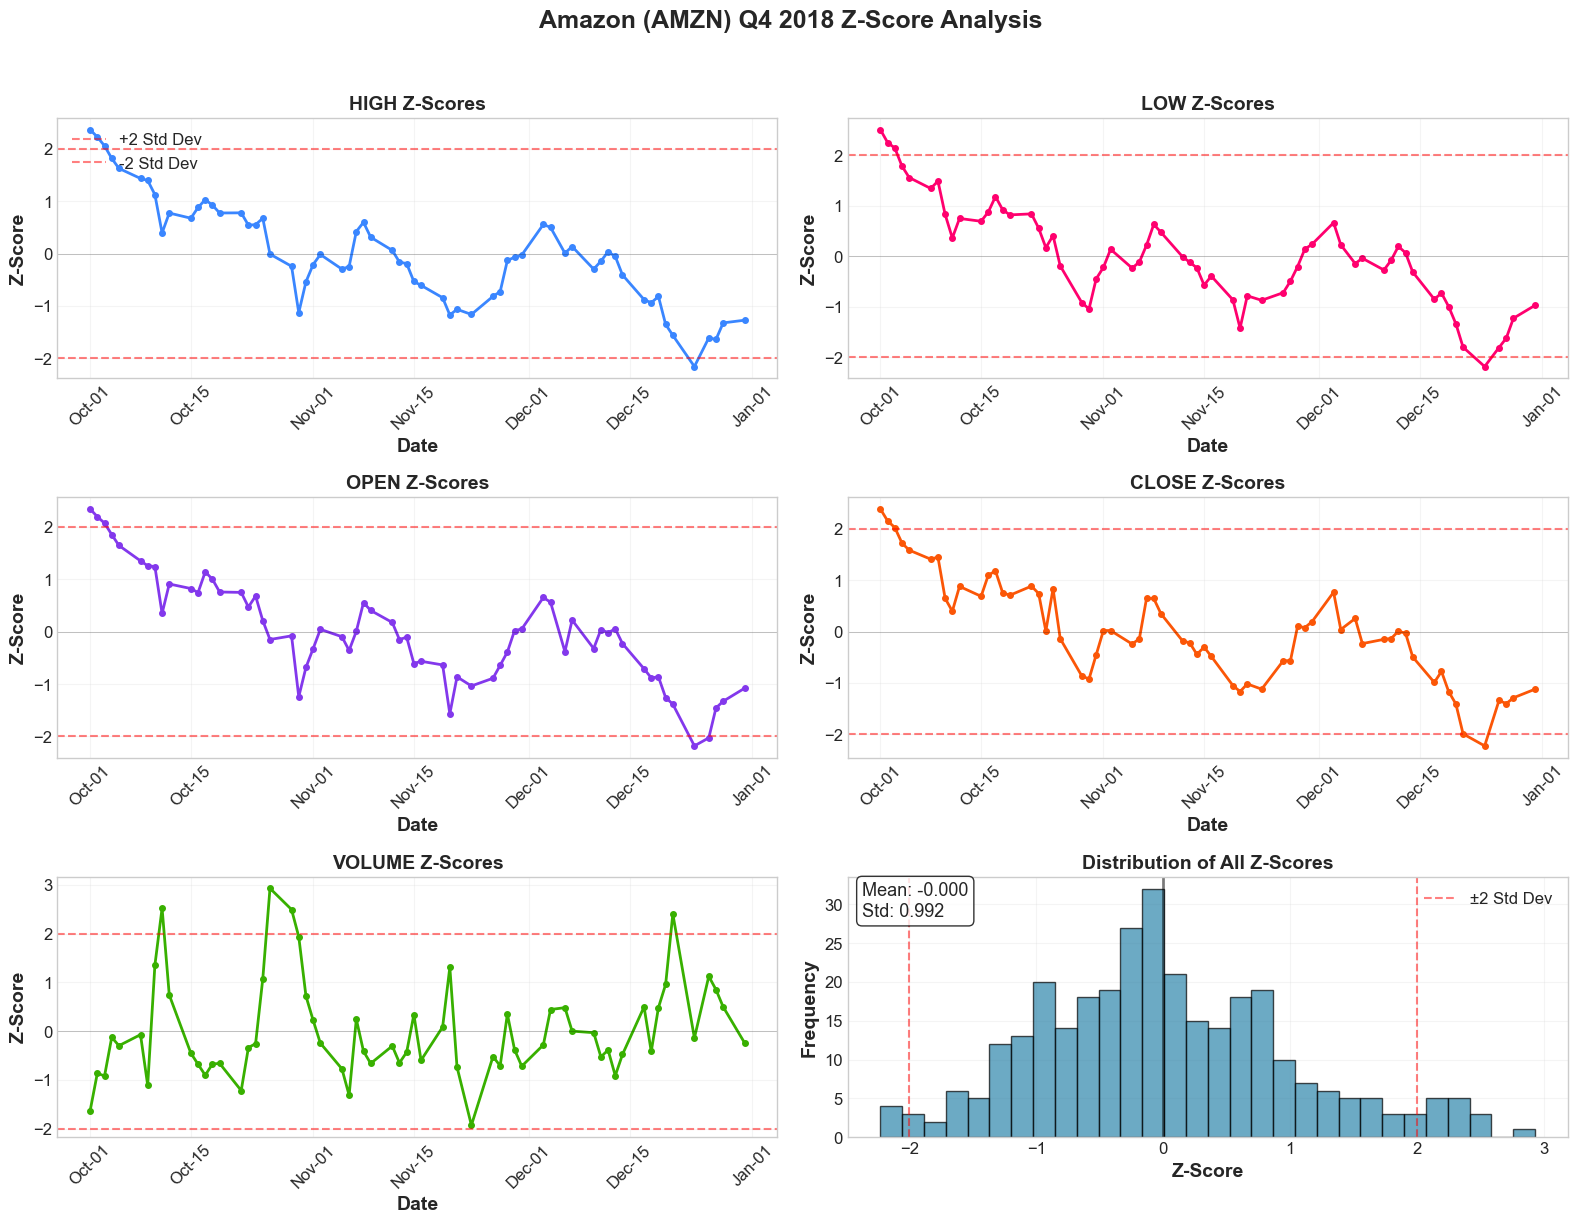


🔗 Z-Score Correlations (How metrics move together):


,high,low,open,close,volume
high,1.000,0.984,0.987,0.978,-0.309
low,0.984,1.000,0.979,0.984,-0.420
open,0.987,0.979,1.000,0.951,-0.344
close,0.978,0.984,0.951,1.000,-0.364
volume,-0.309,-0.420,-0.344,-0.364,1.000


In [6]:
# 1. Filter for Amazon in Q4 2018 (using the datetime index)
amazon_q4 = faang[
    (faang['ticker'] == 'AMZN') &
    (faang.index >= pd.to_datetime('2018-10-01')) &
    (faang.index <= pd.to_datetime('2018-12-31'))
].copy()

print(
    f"📅 Analysis Period: {amazon_q4.index.min().date()} to {amazon_q4.index.max().date()}")
print(f" Trading days in Q4 2018: {len(amazon_q4):,}")
print()

# 2. Format data
amazon_q4['volume'] = amazon_q4['volume'].astype(
    str).str.replace(',', '').astype(float)

# Numeric columns for z-score calculation
numeric_cols = ['high', 'low', 'open', 'close', 'volume']
amazon_numeric = amazon_q4[numeric_cols]

print("💰 Quarterly Statistics (Before Z-Score):")
quarterly_stats = pd.DataFrame({
    'Mean': amazon_numeric.mean(),
    'Std Dev': amazon_numeric.std(),
    'Min': amazon_numeric.min(),
    'Max': amazon_numeric.max()
})
formatted_stats = quarterly_stats.copy()
for col in ['high', 'low', 'open', 'close']:
    formatted_stats.loc[col] = formatted_stats.loc[col].apply(
        lambda x: f'${x:,.2f}')
formatted_stats.loc['volume'] = formatted_stats.loc['volume'].apply(
    lambda x: f'{x:,.0f} shares')

display(formatted_stats)

# 3 & 4: Calculate z-scores using apply()
print("\n🧮 Calculating Z-Scores...")
z_scores = amazon_numeric.apply(lambda x: (x - x.mean()) / x.std())
z_scores.index = amazon_q4.index

print("✅ Z-Score Calculation Complete")
print(" Range of z-scores by column:")
for col in numeric_cols:
    col_min = z_scores[col].min()
    col_max = z_scores[col].max()
    extreme_days = (z_scores[col].abs() > 2).sum()
    print(
        f" • {col}: [{col_min:+.2f}, {col_max:+.2f}] | {extreme_days} days > |2| std dev")
print()

# Display sample
print("📋 Sample Z-Scores (First 10 Trading Days):")
display(z_scores.head(10).style
        .background_gradient(cmap='RdBu', vmin=-3, vmax=3)
        .format('{:+.2f}')
        .set_caption('Negative = Below Average, Positive = Above Average'))

# Find extreme days (z-score > |2|)
extreme_days = {}
for col in numeric_cols:
    extreme_mask = z_scores[col].abs() > 2
    if extreme_mask.any():
        extreme_days[col] = z_scores[extreme_mask][col]

print("\n🚨 Extreme Trading Days (|z-score| > 2):")
if extreme_days:
    for col, extremes in extreme_days.items():
        print(f" {col}: {len(extremes)} extreme day(s)")
        for date, z in extremes.items():
            actual_value = amazon_q4.loc[date, col]  # Use index lookup
            if col == 'volume':
                print(
                    f" • {date.date()}: z={z:+.2f}, actual={actual_value:,.0f} shares")
            else:
                print(
                    f" • {date.date()}: z={z:+.2f}, actual=${actual_value:,.2f}")
else:
    print(" No extreme days found (all |z-scores| ≤ 2)")

# Visualization
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

# Plot 1-5: Z-scores over time for each metric
for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    ax.plot(z_scores.index, z_scores[col],
            color=faang_colors[idx % len(faang_colors)],
            linewidth=2, marker='o', markersize=4)
    ax.axhline(y=2, color='red', linestyle='--', alpha=0.5, label='+2 Std Dev')
    ax.axhline(
        y=-2,
        color='red',
        linestyle='--',
        alpha=0.5,
        label='-2 Std Dev')
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.5)
    ax.set_title(f'{col.upper()} Z-Scores', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Z-Score')
    ax.grid(True, alpha=0.2)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b-%d'))
    ax.tick_params(axis='x', rotation=45)
    if idx == 0:
        ax.legend(loc='upper left')

# Plot 6: Distribution of z-scores (histogram)
ax = axes[5]
all_z_scores = z_scores[numeric_cols].values.flatten()
all_z_scores = all_z_scores[~np.isnan(all_z_scores)]  # Remove NaN
ax.hist(all_z_scores, bins=30, color='#2E86AB', edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='black', linestyle='-', linewidth=2, alpha=0.5)
ax.axvline(x=2, color='red', linestyle='--', alpha=0.5, label='±2 Std Dev')
ax.axvline(x=-2, color='red', linestyle='--', alpha=0.5)
ax.set_title('Distribution of All Z-Scores', fontsize=14, fontweight='bold')
ax.set_xlabel('Z-Score')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.2)
ax.legend()
mean_z = np.mean(all_z_scores)
std_z = np.std(all_z_scores)
ax.text(0.02, 0.98, f'Mean: {mean_z:.3f}\nStd: {std_z:.3f}',
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Amazon (AMZN) Q4 2018 Z-Score Analysis',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Correlation analysis of z-scores
print("\n🔗 Z-Score Correlations (How metrics move together):")
z_corr = z_scores[numeric_cols].corr()
display(z_corr.style
        .background_gradient(cmap='coolwarm', vmin=-1, vmax=1)
        .format('{:.3f}')
        .set_caption('Correlation Matrix: 1 = Perfect Positive, -1 = Perfect Negative'))

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

### Summary

**Core Technique**  
Standardization with z-scores using `apply()`  
- **Z-score formula**: `z = (x - μ) / σ` where μ is mean, σ is standard deviation  
- **`apply()` usage**: Applies a function along DataFrame axis (default: columns)  

**Takeaway**  
Z-scores offer a powerful, scale-independent way to detect anomalies and compare variables, making them indispensable for financial time-series analysis and outlier detection.

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

## **Chapter 4 – Exercise 10: COVID-19 Data Analysis**

### Task
In this exercise, we analyze COVID-19 case data from the European Centre for Disease Prevention and Control using the snapshot in `covid19_cases.csv` (through September 18, 2020). The workflow brings together core data-wrangling skills: date parsing, index management, value standardization, sorting, filtering, and time-series analysis.

### Steps

**Part 1: Data Preparation**  
1. Load and inspect the COVID-19 dataset  
2. Convert date strings (`dateRep`) into proper datetime objects  
3. Set the date column as the DataFrame index  
4. Standardize country names (e.g., 'United_States_of_America' → 'USA', 'United_Kingdom' → 'UK')  
5. Sort the index chronologically  

**Part 2: Top Countries Analysis**  
6. Identify the five countries with the highest cumulative case counts  
7. Determine each country’s peak case day (day with the largest number of new cases)  
8. Compute the 7-day rolling average of new cases for the last week in the data (for the top 5 countries)  

**Part 3: First Cases Analysis**  
9. Determine the first reported case date for each country (excluding China)  

**Part 4: Percentile Ranking**  
10. Rank all countries by cumulative cases using percentile scores  

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

In [7]:
# 1-3 Already completed in setup

# 4. Set the parsed 'dateRep' column as the index
covid = covid.set_index('dateRep')

# 5. Standardize country names
covid['countriesAndTerritories'] = covid['countriesAndTerritories'].replace({
    'United_States_of_America': 'USA',
    'United_Kingdom': 'UK'
})

# 6. Sort the index chronologically
covid = covid.sort_index()

# Display prepared data summary
print("Prepared DataFrame shape:", covid.shape)
print(
    f"Data spans: {covid.index.min().date()} to {covid.index.max().date()}\n")
print("Sample data (after preparation):")
display(covid.head())

# 7. Top 5 countries by cumulative cases
country_totals = covid.groupby('countriesAndTerritories')['cases'].sum()
top5 = country_totals.nlargest(5)
print("\nTop 5 countries by cumulative cases:")
display(top5)

# Peak day per top 5 country
peak_df = (
    covid[covid['countriesAndTerritories'].isin(top5.index)]
    .groupby('countriesAndTerritories')['cases']
    .agg(['idxmax', 'max'])
    .rename(columns={'idxmax': 'Peak Date', 'max': 'Peak Cases'})
)
print("\nDay with largest number of cases for each top 5 country:")
display(peak_df)

# 8. 7-day rolling average of day-to-day case CHANGES — last week (top 5)
daily_cases = (
    covid
    .groupby(['countriesAndTerritories', pd.Grouper(freq='D')])['cases']
    .sum()
    .unstack('countriesAndTerritories')
    .fillna(0)
    .sort_index(axis=1)  # Alphabetical order
)

# Day-to-day change → 7-day rolling mean
daily_change_rolling = daily_cases.diff().rolling(window=7, min_periods=1).mean()

print("\n7-day rolling average of day-to-day case changes — last week of data (top 5 countries):")
display(last_week_change_rolling.style.format('{:.1f}'))

# 9. First case date per country (excluding China)
first_cases = (
    covid[covid['cases'] > 0]
    .query("countriesAndTerritories != 'China'")
    .groupby('countriesAndTerritories')
    .apply(lambda x: x.index.min())
    .rename('First Case Date')
    .sort_values()
    .to_frame()
)
print("\nFirst case dates (excluding China) — earliest 20 shown:")
display(first_cases.head(20))

# 10. Percentile ranking — summary only
percentile_rank = country_totals.rank(pct=True)
rank_table = pd.DataFrame({
    'Cumulative Cases': country_totals,
    'Percentile Rank': percentile_rank
}).sort_values('Percentile Rank', ascending=False)

print("\nSummary: Countries Ranked by Cumulative Cases (Percentile)")
print(f"Total countries: {len(rank_table):,}")
print(f"Median percentile: {rank_table['Percentile Rank'].median():.1%}")
print(
    f"Countries above 90th percentile: {(rank_table['Percentile Rank'] > 0.90).sum()}")

print("\nTop 5 highest-ranked countries:")
display(rank_table.head(5).style.format({
    'Cumulative Cases': '{:,.0f}',
    'Percentile Rank': '{:.1%}'
}))

print("\nBottom 5 lowest-ranked countries:")
display(rank_table.tail(5).style.format({
    'Cumulative Cases': '{:,.0f}',
    'Percentile Rank': '{:.1%}'
}))

print("\nMiddle example (around 50th percentile):")
middle_idx = len(rank_table) // 2
display(rank_table.iloc[middle_idx-2:middle_idx+3].style.format({
    'Cumulative Cases': '{:,.0f}',
    'Percentile Rank': '{:.1%}'
}))

Prepared DataFrame shape: (43718, 11)
Data spans: 2019-12-31 to 2020-09-19

Sample data (after preparation):


,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000
dateRep,,,,,,,,,,,
2019-12-31,31,12,2019,0,0,Belgium,BE,BEL,"11,455,519.00",Europe,NaN
2019-12-31,31,12,2019,0,0,Mexico,MX,MEX,"127,575,529.00",America,NaN
2019-12-31,31,12,2019,0,0,Ecuador,EC,ECU,"17,373,657.00",America,NaN
2019-12-31,31,12,2019,0,0,Russia,RU,RUS,"145,872,260.00",Europe,NaN
2019-12-31,31,12,2019,0,0,Netherlands,NL,NLD,"17,282,163.00",Europe,NaN



Top 5 countries by cumulative cases:


countriesAndTerritories
USA       6724667
India     5308014
Brazil    4495183
Russia    1091186
Peru       756412
Name: cases, dtype: int64


Day with largest number of cases for each top 5 country:


,Peak Date,Peak Cases
countriesAndTerritories,,
Brazil,2020-07-30,69074
India,2020-09-17,97894
Peru,2020-08-17,10143
Russia,2020-07-18,12640
USA,2020-07-25,78427



7-day rolling average of day-to-day case changes — last week of data (top 5 countries):


NameError: name 'last_week_change_rolling' is not defined

<hr style="height:2px; background-color:#999; border:none; margin:30px 0;">

### Summary

**Core Workflow**  
This multi-part exercise applied a full data preparation and analysis pipeline to the ECDC COVID-19 dataset (`covid19_cases.csv`). The process included datetime parsing, index setting, country name standardization, chronological sorting, aggregation, peak detection, rolling change smoothing, first-case identification, and percentile-based ranking.

**Key Techniques Demonstrated**  
- **Datetime handling** — Parsing `dateRep` and setting it as index for time-series operations  
- **Aggregation & grouping** — Cumulative totals, peak days via `idxmax`, daily case reconstruction with `Grouper` + `unstack`  
- **Rolling analysis** — Day-to-day changes (`diff`) smoothed with 7-day rolling mean to reveal trends  
- **Filtering & ranking** — Excluding China for first cases, percentile ranking via `.rank(pct=True)`  


**Takeaway**  
Real-world datasets require careful, sequential preparation before meaningful analysis. Combining datetime indexing, aggregation, rolling windows, and ranking transforms messy case data into clear patterns — a workflow directly applicable to any time-series or public health analysis.

<hr style="height:3px; background-color:#333; border:none; margin:40px 0;">

# Reflection – DSC530 Week 5 & 6 Coding Assignment

**Overall Assignment Experience**  
This assignment provided a strong, practical review of Chapter 4 techniques. Working across three diverse datasets (earthquakes, FAANG stocks, COVID-19 cases) forced repeated application of the same core skills in different contexts — filtering, grouping, aggregation, reshaping, standardization, and visualization. The progression from simple tasks (filtering, binning) to complex multi-step workflows (COVID-19 analysis) built confidence and reinforced how these tools combine in real exploratory data analysis.

**Portions That Were Relatively Straightforward**  
- **Exercises 1–4 (earthquakes)** — Boolean filtering, `pd.cut()`, and `pd.crosstab()` with `aggfunc='max'` felt natural after the book examples. Adding visualizations (timeline scatter, magnitude bars, heatmaps, grouped bars) was fun and intuitive with the global style settings already in place.  
- **Exercise 6 (FAANG pivot)** — `.pivot_table()` with multiple values and mean aggregation was quick to implement, and side-by-side bar charts were easy to extend from previous plotting experience.  
- Initial setup cell — Loading, parsing dates, configuring styles, and previewing datasets became second nature by this point.

**More Challenging Portions**  
- **Exercise 7 (AMZN z-scores)** — Figuring out the date-index issue (KeyError on 'date') required tracing back to the setup cell and adjusting filtering logic to use the index directly. Adding meaningful visualizations (multi-panel time-series + distribution) and extreme-day interpretation took extra debugging and iteration.  
- **Exercise 10 (COVID-19)** — The multi-part nature made it the most complex: ensuring proper date parsing, handling missing days in daily cases, correctly implementing `.diff()` for changes (not just rolling raw cases), and deciding to summarize percentiles instead of dumping 200+ rows. Coordinating the rolling change calculation with `Grouper` + `unstack` + `diff` + `rolling` was the trickiest part to get right.

**Start – Stop – Continue**  
**Start**  
- Regularly check column names, index types, and dtypes early in each exercise — prevents most KeyErrors  
- Add concise summaries (top/bottom/middle) for large outputs like percentiles instead of full tables  
- Include more interpretation prints (e.g., strongest correlations, recent rolling changes) to make results actionable  

**Stop**  
- Assuming column names like 'date' exist without verifying (especially after setup cells modify structure)  
- Printing full large tables (e.g., 200+ country percentiles) — summarize instead  
- Repeating date parsing/loading when setup already handles it  

**Continue**  
- Breaking steps into clear, numbered blocks with prints and displays at each stage  
- Adding thoughtful visualizations (multi-panel plots, gradients, annotations) to complement tables  
- Including performance notes, alternatives, and real-world applications in summaries — deepens understanding  
- Using defensive programming (fillna, dropna, index-based lookups) and vectorized operations  

This assignment reinforced that clean, documented, iterative EDA is as important as the code itself. I feel much more confident chaining pandas operations and turning raw data into meaningful insights.